# Prediksi Penyakit Jantung Pasien Hemodialisa RSU Arun

## Import Library

In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

## Data Cleansing

In [2]:
## Memuat Data dari RSU Arun
df = pd.read_csv("Data_Hd_Arun.csv", sep=";")

print("Total data awal:", df.shape)

# Mengecek nilai kosong (Missing Values)
print("\nJumlah Missing Values:")
print(df.isna().sum())

# Menghapus duplikat jika ada
duplikat_awal = df.duplicated().sum()
if duplikat_awal > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dihapus {duplikat_awal} data duplikat.")

print("Total data bersih siap pakai:", df.shape)

Total data awal: (160, 12)

Jumlah Missing Values:
age                   0
sex                   0
Tensi_Pre_HD          0
Tensi_Post_HD         0
IDWG                  0
Hemoglobin            0
Ureum                 0
Kreatinin             0
Riwayat_Diabetes      0
Riwayat_Hipertensi    0
Lama_Bulan_HD         0
target                0
dtype: int64
Total data bersih siap pakai: (160, 12)


In [3]:
# Feature Engineering (Khusus Pasien HD)
print("FEATURE ENGINEERING")

# 1. Fitur Drop Tensi: Menghitung anjloknya tensi setelah cuci darah
df['Drop_Tensi'] = df['Tensi_Pre_HD'] - df['Tensi_Post_HD']

# 2. Fitur Rasio Ureum/Kreatinin: Menilai efektivitas saringan mesin HD
df['Rasio_Ur_Cr'] = np.round(df['Ureum'] / df['Kreatinin'], 2)

print("Fitur klinis baru berhasil ditambahkan!")
display(df[['Tensi_Pre_HD', 'Tensi_Post_HD', 'Drop_Tensi', 'Ureum', 'Kreatinin', 'Rasio_Ur_Cr']].head())

FEATURE ENGINEERING
Fitur klinis baru berhasil ditambahkan!


,Tensi_Pre_HD,Tensi_Post_HD,Drop_Tensi,Ureum,Kreatinin,Rasio_Ur_Cr
0,145.0,139.0,6.0,218.0,12.3,17.72
1,157.0,117.0,40.0,146.0,9.8,14.90
2,147.0,108.0,39.0,151.0,9.2,16.41
3,200.0,133.0,67.0,252.0,15.4,16.36
4,126.0,127.0,-1.0,140.0,10.8,12.96


## EDA 

EXPLORATORY DATA ANALYSIS (EDA)

1. Ringkasan Statistik Karakteristik Pasien:


,age,sex,Tensi_Pre_HD,Tensi_Post_HD,IDWG,Hemoglobin,Ureum,Kreatinin,Riwayat_Diabetes,Riwayat_Hipertensi,Lama_Bulan_HD,target,Drop_Tensi,Rasio_Ur_Cr
count,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.00,160.0,160.00,160.00
mean,51.41,0.60,142.61,125.77,3.51,9.66,160.42,10.85,0.56,0.69,49.36,0.5,16.84,14.78
std,18.14,0.49,21.50,15.30,1.69,2.09,44.59,2.71,0.50,0.46,28.72,0.5,22.54,1.69
min,17.00,0.00,100.00,90.00,1.00,6.00,82.00,6.00,0.00,0.00,6.00,0.0,-36.00,11.98
25%,38.00,0.00,127.00,114.75,2.20,8.05,127.00,8.60,0.00,0.00,28.50,0.0,0.00,13.22
50%,52.00,1.00,141.00,124.50,3.00,9.60,152.00,10.45,1.00,1.00,45.00,0.5,16.00,14.83
75%,68.00,1.00,156.00,136.00,4.58,11.08,194.25,12.60,1.00,1.00,66.50,1.0,35.00,16.18
max,80.00,1.00,200.00,160.00,7.50,14.00,289.00,18.00,1.00,1.00,133.00,1.0,73.00,17.87


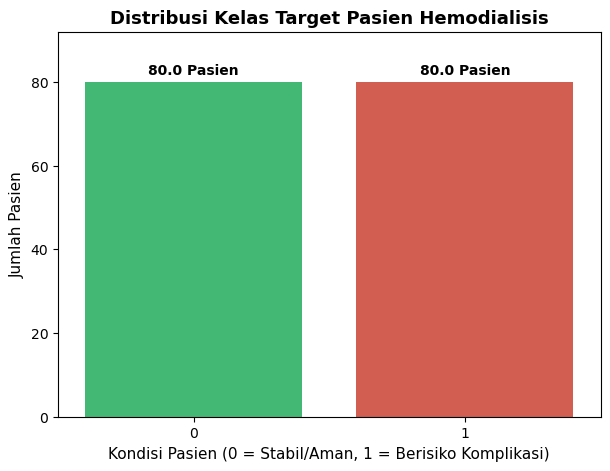

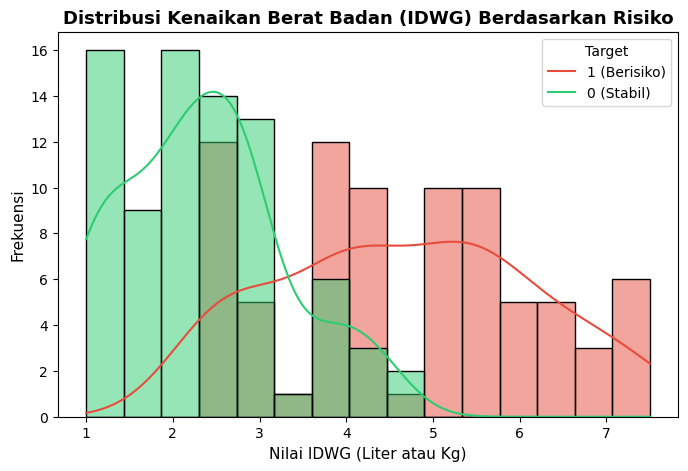

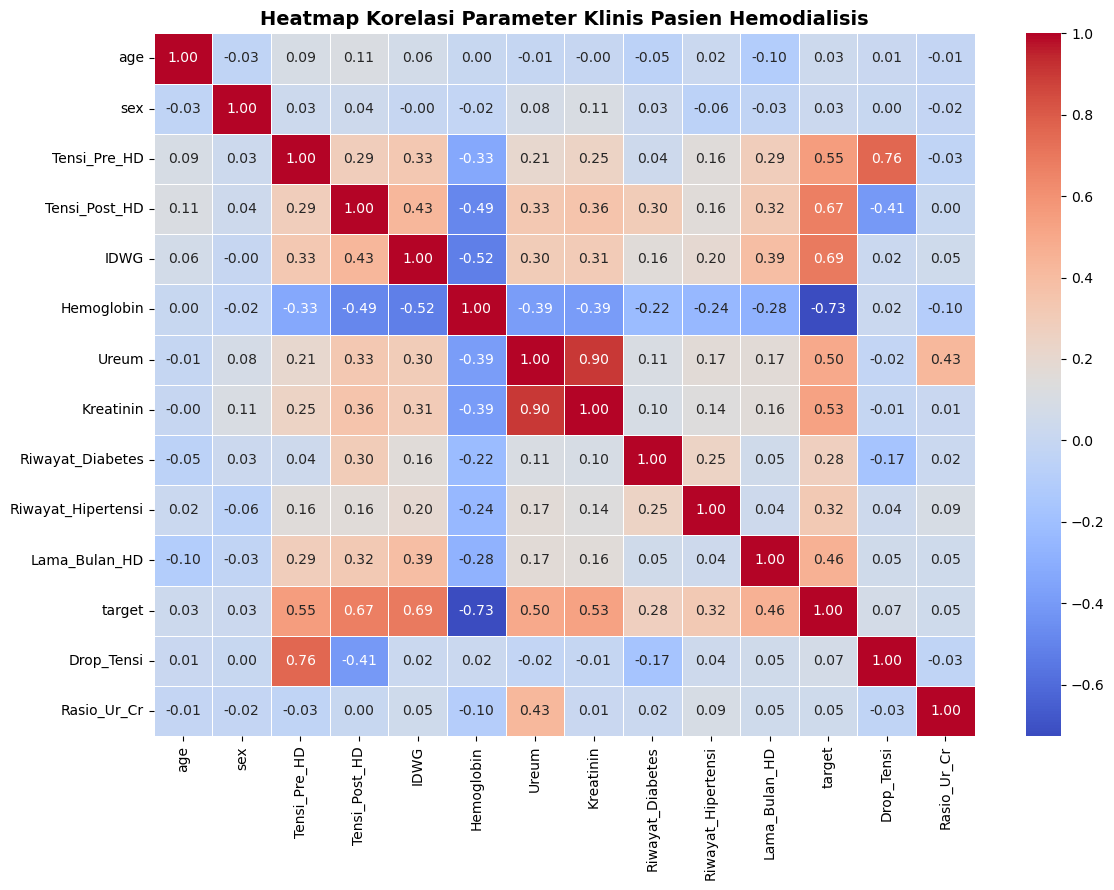

In [4]:
# EDA - Visualisasi Distribusi dan Korelasi
print("EXPLORATORY DATA ANALYSIS (EDA)")

# 1. Menampilkan Statistik Deskriptif (Untuk disalin ke Tabel Karakteristik Pasien di Jurnal)
print("\n1. Ringkasan Statistik Karakteristik Pasien:")
display(df.describe().round(2))

# 2. Visualisasi Distribusi Target (Pasien Stabil vs Berisiko)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='target', palette=['#2ECC71', '#E74C3C']) # Hijau untuk Aman, Merah untuk Bahaya
plt.title('Distribusi Kelas Target Pasien Hemodialisis', fontweight='bold', fontsize=13)
plt.xlabel('Kondisi Pasien (0 = Stabil/Aman, 1 = Berisiko Komplikasi)', fontsize=11)
plt.ylabel('Jumlah Pasien', fontsize=11)

# Menambahkan angka di atas masing-masing batang grafik
for p in ax.patches:
    ax.annotate(f'{p.get_height()} Pasien', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')
plt.ylim(0, df['target'].value_counts().max() * 1.15) # Memberi ruang kosong di atas grafik
plt.show()

# 3. Visualisasi Ekstra Jurnal: Perbandingan IDWG antara pasien Sehat vs Sakit
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='IDWG', hue='target', kde=True, palette=['#2ECC71', '#E74C3C'], bins=15)
plt.title('Distribusi Kenaikan Berat Badan (IDWG) Berdasarkan Risiko', fontweight='bold', fontsize=13)
plt.xlabel('Nilai IDWG (Liter atau Kg)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.legend(title='Target', labels=['1 (Berisiko)', '0 (Stabil)'])
plt.show()

# 4. Visualisasi Heatmap Korelasi
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Parameter Klinis Pasien Hemodialisis', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## Additional Data Preparation befor Modeling

In [5]:
# Sel 5: Pembagian dan Penskalaan Data
print("SPLIT & SCALING DATA")

# Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['target'])
y = df['target']

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensi X_train (Data Latih): {X_train_scaled.shape}")
print(f"Dimensi X_test (Data Uji): {X_test_scaled.shape}")

SPLIT & SCALING DATA
Dimensi X_train (Data Latih): (128, 13)
Dimensi X_test (Data Uji): (32, 13)


## Modeling

TRAINING & EVALUASI DECISION TREE
Laporan Klasifikasi (Classification Report):
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        18

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32

Akurasi Decision Tree: 0.9688



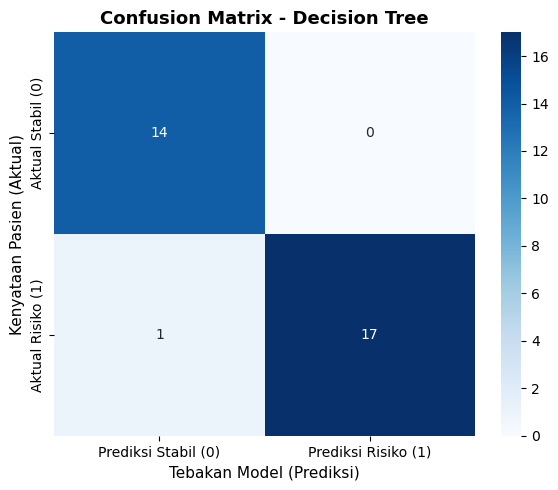

In [6]:
# Sel 6: Model Decision Tree (Baseline) beserta Evaluasinya
print("TRAINING & EVALUASI DECISION TREE")

# 1. Inisialisasi dan Pelatihan Model
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_scaled, y_train)

# 2. Melakukan Prediksi pada Data Uji
y_pred_dtree = dtree.predict(X_test_scaled)

# 3. Menampilkan Laporan Metrik Evaluasi
print("Laporan Klasifikasi (Classification Report):")
print(classification_report(y_test, y_pred_dtree))
print(f"Akurasi Decision Tree: {accuracy_score(y_test, y_pred_dtree):.4f}\n")

# 4. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
# Membuat heatmap, nilai 'y_test' disandingkan dengan tebakan 'y_pred_dtree'
sns.heatmap(confusion_matrix(y_test, y_pred_dtree), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Stabil (0)', 'Prediksi Risiko (1)'],
            yticklabels=['Aktual Stabil (0)', 'Aktual Risiko (1)'])

plt.title('Confusion Matrix - Decision Tree', fontweight='bold', fontsize=13)
plt.xlabel('Tebakan Model (Prediksi)', fontsize=11)
plt.ylabel('Kenyataan Pasien (Aktual)', fontsize=11)
plt.tight_layout()
plt.show()

OPTIMASI RANDOM FOREST (TUNING) & EVALUASI
Sedang mencari parameter terbaik menggunakan GridSearchCV...

🏆 Optimasi Selesai!
Parameter Terbaik yang Ditemukan: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 50}

Laporan Klasifikasi (Classification Report) - Model Terbaik:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        18

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32

Akurasi RF-Optimized: 0.9688



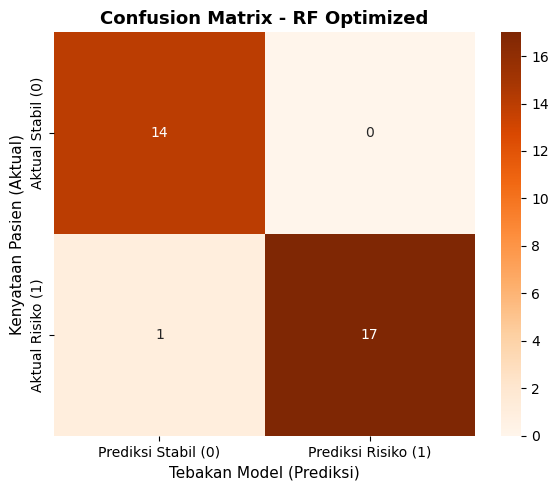

In [7]:
# Hyperparameter Tuning & Evaluasi rf_best
# ==========================================
# IMPORT TAMBAHAN METRIK KHUSUS (Mencegah Error jika sel di-run terpisah)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# ==========================================

print("OPTIMASI RANDOM FOREST (TUNING) & EVALUASI")
print("Sedang mencari parameter terbaik menggunakan GridSearchCV...\n")

# 1. Menentukan Parameter Uji
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'n_estimators': [50, 100, 150]
}

# 2. Proses Pencarian Model Terbaik (Fokus mengejar AUC tertinggi)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

# 3. Mengambil Model Terbaik
rf_best = grid_search.best_estimator_

print("🏆 Optimasi Selesai!")
print(f"Parameter Terbaik yang Ditemukan: {grid_search.best_params_}\n")

# 4. Melakukan Prediksi pada Data Uji
y_pred_best = rf_best.predict(X_test_scaled)

# 5. Menampilkan Laporan Metrik Evaluasi
print("Laporan Klasifikasi (Classification Report) - Model Terbaik:")
print(classification_report(y_test, y_pred_best))
print(f"Akurasi RF-Optimized: {accuracy_score(y_test, y_pred_best):.4f}\n")

# 6. Visualisasi Confusion Matrix Emas
plt.figure(figsize=(6, 5))
# Membuat heatmap dengan tema warna 'Oranges'
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prediksi Stabil (0)', 'Prediksi Risiko (1)'],
            yticklabels=['Aktual Stabil (0)', 'Aktual Risiko (1)'])

plt.title('Confusion Matrix - RF Optimized', fontweight='bold', fontsize=13)
plt.xlabel('Tebakan Model (Prediksi)', fontsize=11)
plt.ylabel('Kenyataan Pasien (Aktual)', fontsize=11)
plt.tight_layout()
plt.show()

   TRAINING & EVALUASI SVM (BASELINE)

Laporan Klasifikasi (Classification Report):
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        18

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32

Akurasi SVM Baseline : 0.9688
AUC Score SVM Baseline: 0.9960



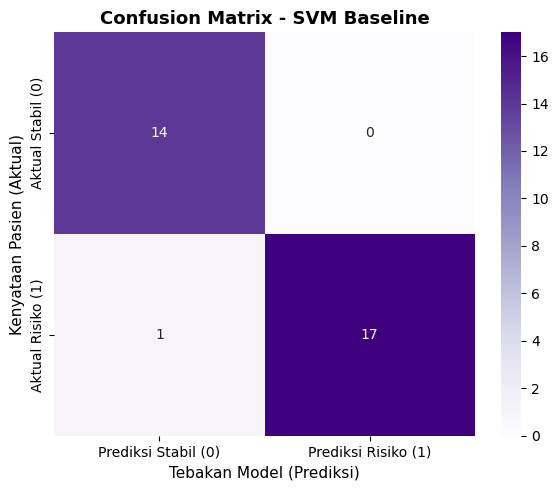

   OPTIMASI SVM (TUNING) & EVALUASI
Sedang mencari parameter terbaik menggunakan GridSearchCV...

Optimasi Selesai!
Parameter Terbaik yang Ditemukan: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
AUC Score CV Terbaik            : 0.9988

Laporan Klasifikasi (Classification Report) - SVM Optimized:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        18

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32

Akurasi SVM Optimized : 0.9688



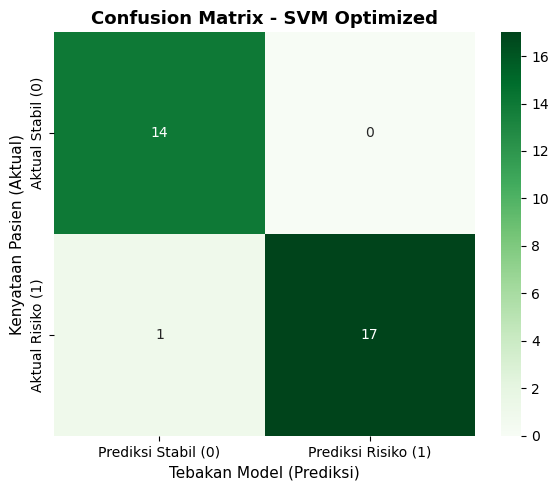

   TABEL KOMPARASI PERFORMA 3 MODEL

Tabel Komparasi Performa Model (Dibulatkan 4 Desimal - Standar Jurnal):


,Accuracy,Precision,Recall (Sensitivitas),F1-Score,AUC Score
Algoritma Model,,,,,
1. Decision Tree (Baseline),0.9688,1.0,0.9444,0.9714,0.9722
2. Random Forest (Optimized),0.9688,1.0,0.9444,0.9714,0.9960
3. SVM (Optimized),0.9688,1.0,0.9444,0.9714,0.9921



--- Nilai Terbaik per Metrik ---
  Accuracy                 : 1. Decision Tree (Baseline)  (0.9688)
  Precision                : 1. Decision Tree (Baseline)  (1.0000)
  Recall (Sensitivitas)    : 1. Decision Tree (Baseline)  (0.9444)
  F1-Score                 : 1. Decision Tree (Baseline)  (0.9714)
  AUC Score                : 2. Random Forest (Optimized)  (0.9960)
   ROC CURVE — PERBANDINGAN 3 MODEL


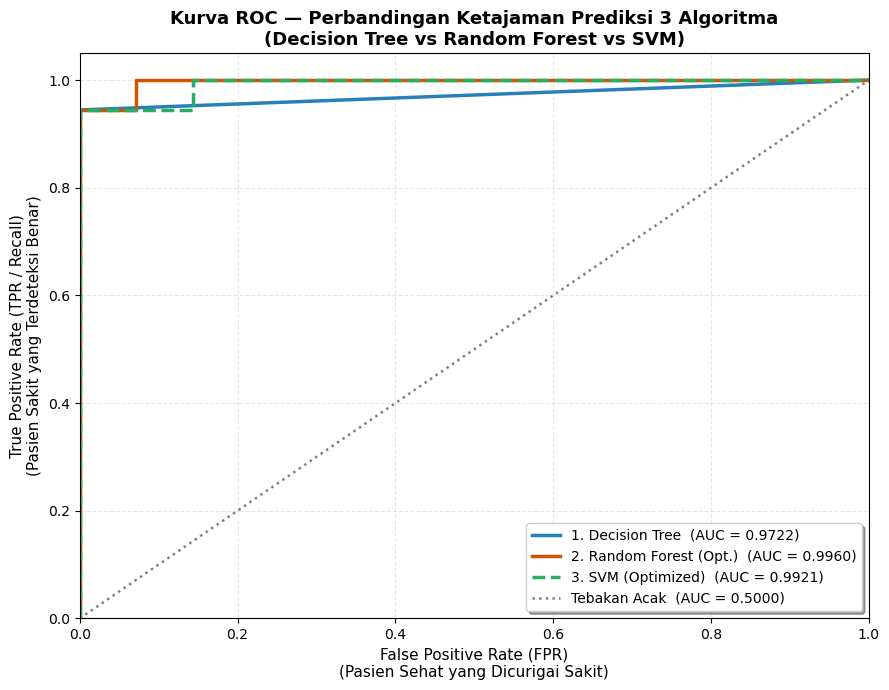


Analisis ROC Curve Selesai.
Model dengan AUC tertinggi adalah model terbaik untuk direkomendasikan.


In [8]:
#TAMBAHAN MODEL SVM - PASTE KE NOTEBOOK SETELAH SEL RANDOM FOREST

#SVM BASELINE

from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 55)
print("   TRAINING & EVALUASI SVM (BASELINE)")
print("=" * 55)

# 1. Inisialisasi dan Pelatihan Model SVM Baseline
#    probability=True wajib diaktifkan agar bisa menghitung AUC Score
svm_baseline = SVC(kernel='rbf', random_state=42, probability=True)
svm_baseline.fit(X_train_scaled, y_train)

# 2. Melakukan Prediksi pada Data Uji
y_pred_svm = svm_baseline.predict(X_test_scaled)

# 3. Menampilkan Laporan Metrik Evaluasi
print("\nLaporan Klasifikasi (Classification Report):")
print(classification_report(y_test, y_pred_svm))
print(f"Akurasi SVM Baseline : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"AUC Score SVM Baseline: {roc_auc_score(y_test, svm_baseline.predict_proba(X_test_scaled)[:, 1]):.4f}\n")

# 4. Visualisasi Confusion Matrix SVM Baseline
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prediksi Stabil (0)', 'Prediksi Risiko (1)'],
            yticklabels=['Aktual Stabil (0)', 'Aktual Risiko (1)'])
plt.title('Confusion Matrix - SVM Baseline', fontweight='bold', fontsize=13)
plt.xlabel('Tebakan Model (Prediksi)', fontsize=11)
plt.ylabel('Kenyataan Pasien (Aktual)', fontsize=11)
plt.tight_layout()
plt.show()


# SEL BARU 2: SVM TUNED (GRIDSEARCHCV)

from sklearn.model_selection import GridSearchCV

print("=" * 55)
print("   OPTIMASI SVM (TUNING) & EVALUASI")
print("=" * 55)
print("Sedang mencari parameter terbaik menggunakan GridSearchCV...\n")

# 1. Menentukan Grid Parameter Uji untuk SVM
#    - C       : Mengontrol toleransi kesalahan (margin vs akurasi)
#    - kernel  : Fungsi pemisah batas (rbf=lengkung, linear=garis lurus)
#    - gamma   : Jangkauan pengaruh tiap titik data
param_grid_svm = {
    'C'      : [0.1, 1, 10, 100],
    'kernel' : ['rbf', 'linear', 'poly'],
    'gamma'  : ['scale', 'auto']
}

# 2. Proses Pencarian Model Terbaik (Fokus mengejar AUC tertinggi)
grid_search_svm = GridSearchCV(
    estimator  = SVC(random_state=42, probability=True),
    param_grid = param_grid_svm,
    cv         = 5,
    scoring    = 'roc_auc',
    n_jobs     = -1
)
grid_search_svm.fit(X_train_scaled, y_train)

# 3. Mengambil Model Terbaik
svm_best = grid_search_svm.best_estimator_

print("Optimasi Selesai!")
print(f"Parameter Terbaik yang Ditemukan: {grid_search_svm.best_params_}")
print(f"AUC Score CV Terbaik            : {grid_search_svm.best_score_:.4f}\n")

# 4. Melakukan Prediksi pada Data Uji
y_pred_svm_best = svm_best.predict(X_test_scaled)

# 5. Menampilkan Laporan Metrik Evaluasi
print("Laporan Klasifikasi (Classification Report) - SVM Optimized:")
print(classification_report(y_test, y_pred_svm_best))
print(f"Akurasi SVM Optimized : {accuracy_score(y_test, y_pred_svm_best):.4f}\n")

# 6. Visualisasi Confusion Matrix SVM Optimized
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_best),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prediksi Stabil (0)', 'Prediksi Risiko (1)'],
            yticklabels=['Aktual Stabil (0)', 'Aktual Risiko (1)'])
plt.title('Confusion Matrix - SVM Optimized', fontweight='bold', fontsize=13)
plt.xlabel('Tebakan Model (Prediksi)', fontsize=11)
plt.ylabel('Kenyataan Pasien (Aktual)', fontsize=11)
plt.tight_layout()
plt.show()

# SEL BARU 3: TABEL KOMPARASI 3 MODEL (DT vs RF vs SVM) 


import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

print("=" * 55)
print("   TABEL KOMPARASI PERFORMA 3 MODEL")
print("=" * 55)

# Fungsi Universal: Menghitung semua metrik sekaligus untuk model apapun
def hitung_semua_metrik(model, nama_model, X_uji, y_uji):
    y_pred = model.predict(X_uji)
    y_prob = model.predict_proba(X_uji)[:, 1]
    return {
        "Algoritma Model"      : nama_model,
        "Accuracy"             : round(accuracy_score(y_uji, y_pred),  4),
        "Precision"            : round(precision_score(y_uji, y_pred), 4),
        "Recall (Sensitivitas)": round(recall_score(y_uji, y_pred),    4),
        "F1-Score"             : round(f1_score(y_uji, y_pred),        4),
        "AUC Score"            : round(roc_auc_score(y_uji, y_prob),   4)
    }

# Kumpulkan metrik dari ketiga model
metrik_dtree    = hitung_semua_metrik(dtree,    "1. Decision Tree (Baseline)",   X_test_scaled, y_test)
metrik_rf_best  = hitung_semua_metrik(rf_best,  "2. Random Forest (Optimized)",  X_test_scaled, y_test)
metrik_svm_best = hitung_semua_metrik(svm_best, "3. SVM (Optimized)",            X_test_scaled, y_test)

# Gabungkan ke dalam satu DataFrame tabel
df_komparasi = pd.DataFrame([metrik_dtree, metrik_rf_best, metrik_svm_best])
df_komparasi.set_index("Algoritma Model", inplace=True)

print("\nTabel Komparasi Performa Model (Dibulatkan 4 Desimal - Standar Jurnal):")
display(df_komparasi)

# Highlight otomatis nilai terbaik di setiap kolom metrik
print("\n--- Nilai Terbaik per Metrik ---")
for col in df_komparasi.columns:
    best_model = df_komparasi[col].idxmax()
    best_val   = df_komparasi[col].max()
    print(f"  {col:<25}: {best_model}  ({best_val:.4f})")


# ROC CURVE PERBANDINGAN 3 MODEL        


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

print("=" * 55)
print("   ROC CURVE — PERBANDINGAN 3 MODEL")
print("=" * 55)

plt.figure(figsize=(9, 7))

# Daftar model, warna, dan gaya garis masing-masing
models_to_plot = {
    "1. Decision Tree"       : (dtree,    '#2980B9', '-'),   # Biru solid
    "2. Random Forest (Opt.)": (rf_best,  '#D35400', '-'),   # Oranye solid
    "3. SVM (Optimized)"     : (svm_best, '#27AE60', '--'),  # Hijau putus-putus
}

for nama, (model, warna, gaya) in models_to_plot.items():
    y_prob  = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr,
             color=warna, lw=2.5, linestyle=gaya,
             label=f'{nama}  (AUC = {auc_val:.4f})')

# Garis baseline: tebakan acak
plt.plot([0, 1], [0, 1],
         color='gray', lw=1.8, linestyle=':',
         label='Tebakan Acak  (AUC = 0.5000)')

# Estetika grafik — standar jurnal SINTA
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)\n(Pasien Sehat yang Dicurigai Sakit)',  fontsize=11)
plt.ylabel('True Positive Rate (TPR / Recall)\n(Pasien Sakit yang Terdeteksi Benar)', fontsize=11)
plt.title('Kurva ROC — Perbandingan Ketajaman Prediksi 3 Algoritma\n(Decision Tree vs Random Forest vs SVM)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nAnalisis ROC Curve Selesai.")
print("Model dengan AUC tertinggi adalah model terbaik untuk direkomendasikan.")

ANALISIS FITUR PENENTU (FEATURE IMPORTANCE)


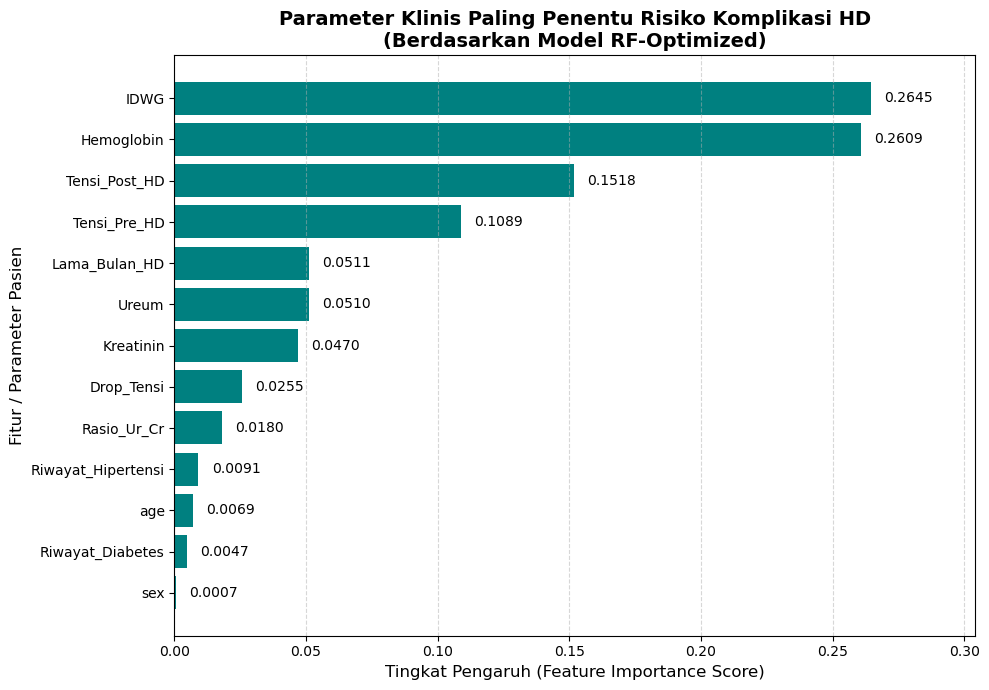

In [9]:
# Analisis Fitur Medis Paling Berpengaruh
print("ANALISIS FITUR PENENTU (FEATURE IMPORTANCE)")

# 1. Mengekstrak nilai "kepentingan" dari model Random Forest terbaik (rf_best)
importances = rf_best.feature_importances_

# 2. Membuat DataFrame agar mudah diurutkan
feature_imp_df = pd.DataFrame({
    'Parameter Medis': X.columns,
    'Skor Kepentingan': importances
})

# Mengurutkan dari yang terkecil ke terbesar untuk tampilan bar chart horizontal
feature_imp_df = feature_imp_df.sort_values(by='Skor Kepentingan', ascending=True)

# 3. Visualisasi Grafik Batang (Bar Chart)
plt.figure(figsize=(10, 7))
# Menggunakan warna 'teal' agar terlihat profesional dan medis
bars = plt.barh(feature_imp_df['Parameter Medis'], feature_imp_df['Skor Kepentingan'], color='teal')

# Menambahkan angka detail di ujung setiap batang
for bar in bars:
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', 
             va='center', ha='left', fontsize=10)

# Merapikan tampilan grafik
plt.title('Parameter Klinis Paling Penentu Risiko Komplikasi HD\n(Berdasarkan Model RF-Optimized)', fontweight='bold', fontsize=14)
plt.xlabel('Tingkat Pengaruh (Feature Importance Score)', fontsize=12)
plt.ylabel('Fitur / Parameter Pasien', fontsize=12)
plt.xlim(0, feature_imp_df['Skor Kepentingan'].max() * 1.15) # Memberi ruang untuk teks angka
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()